# Análisis de Olist

Este notebook se utiliza para cargar y analizar los datos del proyecto Olist.

## Estructura de Datos
Los datos se encuentran en la carpeta `Datos`, divididos en:
- `Tablas-Marketing`: Contiene información sobre leads y deals cerrados.
- `Tablas-Ordenes`: Contiene el núcleo de la información de e-commerce (clientes, órdenes, productos, etc.).

In [17]:
import pandas as pd
import os

# Definir rutas a los archivos
base_path = 'Datos'
marketing_path = os.path.join(base_path, 'Tablas-Marketing', 'archive (2)')
ordenes_path = os.path.join(base_path, 'Tablas-Ordenes')

# Cargar Tablas de Marketing
closed_deals = pd.read_csv(os.path.join(marketing_path, 'olist_closed_deals_dataset.csv'))
marketing_qualified_leads = pd.read_csv(os.path.join(marketing_path, 'olist_marketing_qualified_leads_dataset.csv'))

# Cargar Tablas de Ordenes
# Esta vez, vamos a usar un nombre diferente en la carga de tabla de datos.
customers = pd.read_csv(os.path.join(ordenes_path, 'olist_customers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(ordenes_path, 'olist_geolocation_dataset.csv'))
order_items = pd.read_csv(os.path.join(ordenes_path, 'olist_order_items_dataset.csv'))
order_payments = pd.read_csv(os.path.join(ordenes_path, 'olist_order_payments_dataset.csv'))
order_reviews = pd.read_csv(os.path.join(ordenes_path, 'olist_order_reviews_dataset.csv'))
orders = pd.read_csv(os.path.join(ordenes_path, 'olist_orders_dataset.csv'))
products = pd.read_csv(os.path.join(ordenes_path, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(ordenes_path, 'olist_sellers_dataset.csv'))
product_category_translation = pd.read_csv(os.path.join(ordenes_path, 'product_category_name_translation.csv'))

# Verificar la carga mostrando las dimensiones de cada DataFrame
datasets = {
    'Closed Deals': closed_deals,
    'Marketing Qualified Leads': marketing_qualified_leads,
    'Customers': customers,
    'Geolocation': geolocation,
    'Order Items': order_items,
    'Order Payments': order_payments,
    'Order Reviews': order_reviews,
    'Orders': orders,
    'Products': products,
    'Sellers': sellers,
    'Category Translation': product_category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Closed Deals: (842, 14)
Marketing Qualified Leads: (8000, 4)
Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


# Análisis Exploratorio

Vamos a hacer un análisis exploratorio muy basico respondiendo a algunas preguntas clave.

### Producto más vendido

In [18]:
order_items['product_id'].value_counts().head(1)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
Name: count, dtype: int64

### Vendedor que vendió más

In [19]:
order_items['seller_id'].value_counts().head(1)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
Name: count, dtype: int64

### Con qué medio pagan más en general en Brasil

In [20]:
order_payments['payment_type'].value_counts().head(1)

payment_type
credit_card    76795
Name: count, dtype: int64

El medio de pago predilecto es la "tarjeta de credito"

### Cuál es la cantidad más frecuente de cuotas que pagan en un pedido

In [21]:
order_payments['payment_installments'].value_counts().head(1)

payment_installments
1    52546
Name: count, dtype: int64

1 cuota es la cantidad mas frecuente de cuotas en la que suelen pagar los pedidos.

## Analisis Exploratorio de Datos profundo:
Hagamos ahora un analisis exploratorio de datos mas profundo y detallado para estudiar el comportamiento mas general de los datos y no simplemente preguntas sueltas, en la medida de lo posible tratare de plantear preguntas que intenten ser relevantes.


### 1. Cantidad de Sellers por Estado
Este gráfico muestra la distribución geográfica de los vendedores en Brasil, utilizando las abreviaturas de los estados.

C:\Users\locu\AppData\Local\Temp\ipykernel_42724\4047952794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')


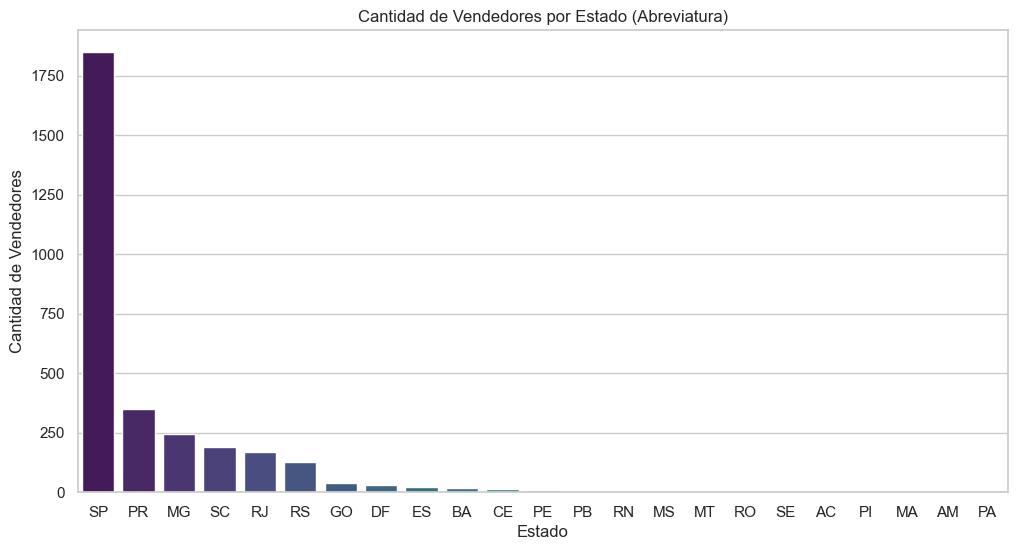

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
state_order = sellers['seller_state'].value_counts().index
sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')
plt.title('Cantidad de Vendedores por Estado (Abreviatura)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Vendedores')
plt.show()

El estado por mucho que mas vendedores tiene es Sao Paulo por mucho, seria interesante preguntar porque ¿Es la zona mas rica?.Para apreciar bien como lso valores de los estados con menor cantidad de vendedores vamos a hacer el mismo grafico pero en con escala logaritmica en el eje Y.

### 1.2. Cantidad de Sellers por Estado (Escala Logarítmica)


C:\Users\locu\AppData\Local\Temp\ipykernel_42724\1482405418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')


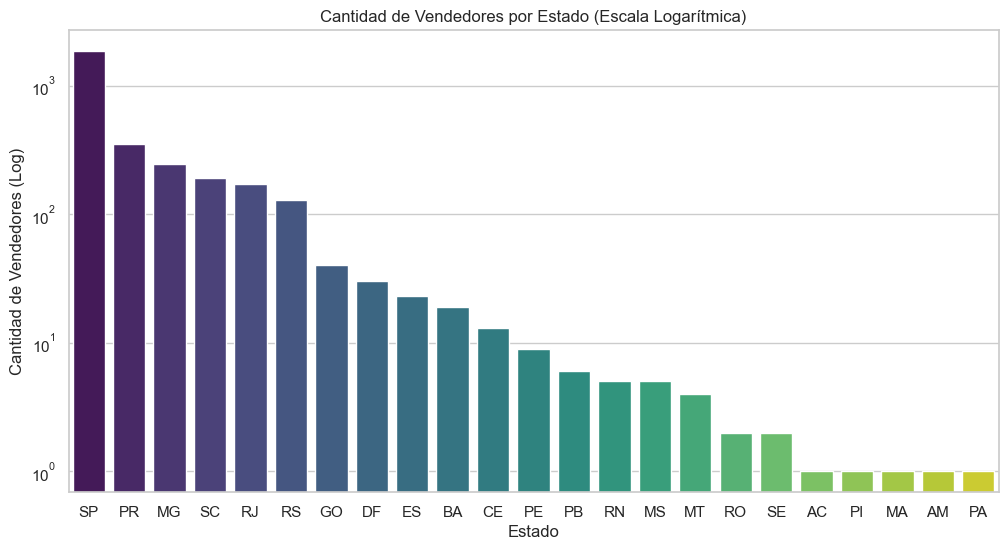

In [31]:
plt.figure(figsize=(12, 6))
state_order = sellers['seller_state'].value_counts().index
ax = sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')
ax.set_yscale("log")
plt.title('Cantidad de Vendedores por Estado (Escala Logarítmica)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Vendedores (Log)')
plt.show()

### 2. Cantidad de Compradores por Estado
Visualización de la distribución de clientes por estado.

C:\Users\locu\AppData\Local\Temp\ipykernel_42724\2696803699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customers, x='customer_state', order=customer_state_order, palette='magma')


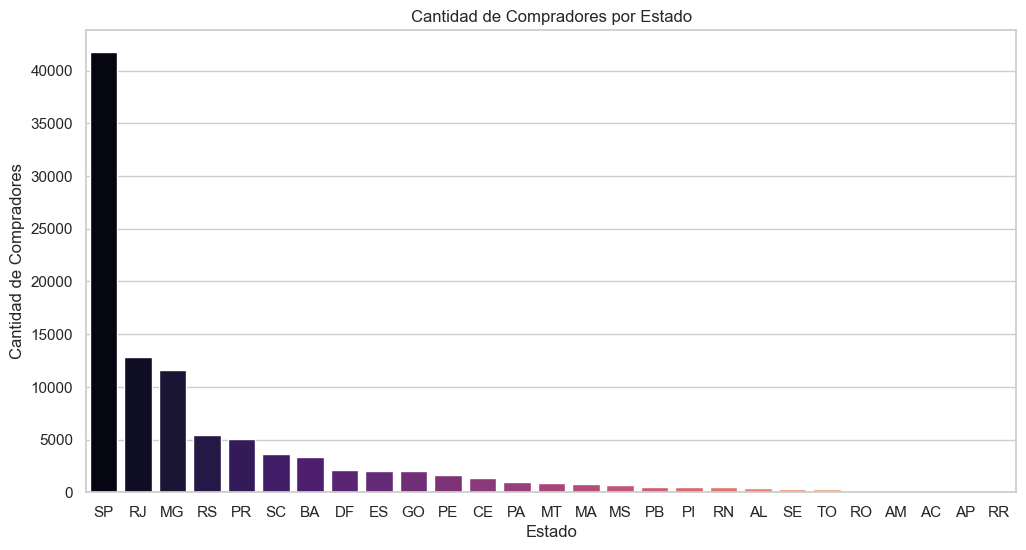

In [ ]:
plt.figure(figsize=(12, 6))
customer_state_order = customers['customer_state'].value_counts().index
sns.countplot(data=customers, x='customer_state', order=customer_state_order, palette='magma')
plt.title('Cantidad de Compradores por Estado')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Compradores')
plt.show()

El estado con mas compradores nuevamente es Sao Paulo, pero luego difieren en el orden de los estados mas vendedores, nuevamente voy aplicar escala logaritmica para poder apreciar la cantidad de compradores de los estados con menor cantidad

## 2.2  Cantidad de compradores por Estado (Escala Logarítmica)

### 3. Proporción de Compradores por Vendedor por Estado
Este gráfico representa cuántos compradores hay por cada vendedor en cada estado, permitiendo identificar niveles de competencia o demanda relativa.

C:\Users\locu\AppData\Local\Temp\ipykernel_42724\2323093090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['ratio'], palette='plasma')


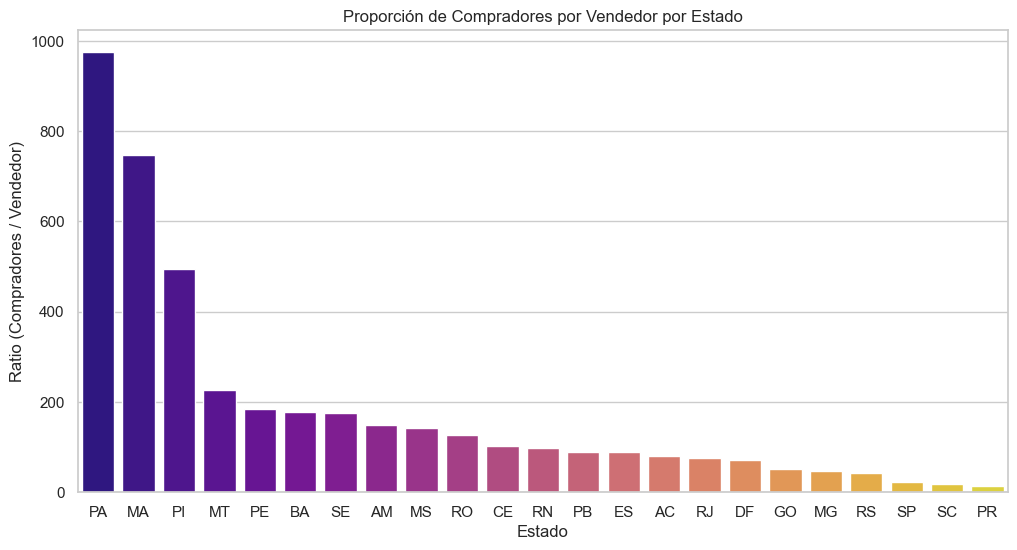

In [33]:
sellers_counts = sellers['seller_state'].value_counts()
customers_counts = customers['customer_state'].value_counts()
df_counts = pd.DataFrame({'sellers': sellers_counts, 'customers': customers_counts}).fillna(0)
df_counts['ratio'] = df_counts['customers'] / df_counts['sellers']
# Filtramos estados sin vendedores para evitar divisiones por cero/infinito
df_counts = df_counts[df_counts['sellers'] > 0].sort_values('ratio', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=df_counts.index, y=df_counts['ratio'], palette='plasma')
plt.title('Proporción de Compradores por Vendedor por Estado')
plt.xlabel('Estado')
plt.ylabel('Ratio (Compradores / Vendedor)')
plt.show()



Es curioso que en el ratio compradores/vendedores la jerarquia casi que se invierte, los paises que tenian pocos vendedores y compradores aparecen primero, y los estados como Sau paulo quedan casi ultimo.Por lo que en el caso de "Para" (PA) se muestra que tiene casi 1000 veces mas compradores que vendedores. una buena pregunta seria ¿Las compras que hacen los habitantes de esa region, son locales ?.Podria indicar una buena opcion de negocio, faltaria comprar esto en funcion de los habitantes y la calidad de los productos que comercializan los vendedores asi como la que compran los compradores.Veamos el data frame para analizarlo mejor

In [34]:
display(df_counts)

,sellers,customers,ratio
PA,1.0,975,975.000000
MA,1.0,747,747.000000
PI,1.0,495,495.000000
MT,4.0,907,226.750000
PE,9.0,1652,183.555556
BA,19.0,3380,177.894737
SE,2.0,350,175.000000
AM,1.0,148,148.000000
MS,5.0,715,143.000000
RO,2.0,253,126.500000


Podemos observar que hay muchos estados con 1 solo seller

### 4. Análisis de Montos de Pagos y ECDF
Distribución de montos y Función de Distribución Acumulada Empírica (ECDF) con media y desviaciones estándar.

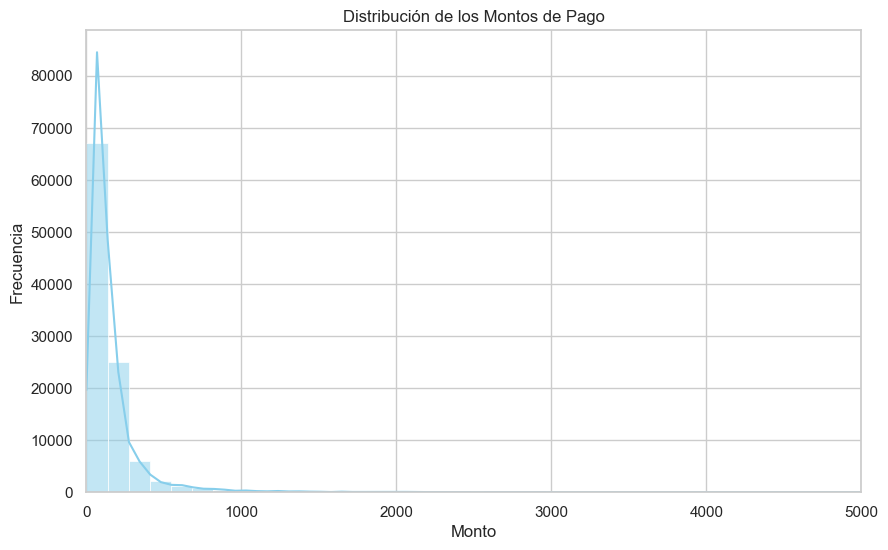

In [29]:
# Histograma
plt.figure(figsize=(10, 6))
sns.histplot(order_payments['payment_value'], bins=100, kde=True, color='skyblue')
plt.title('Distribución de los Montos de Pago')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.xlim(0, 5000)
plt.show()


Podemso ver que la mayor parte de los datos se acumulan enntre aproximadamente los precios menores a 250 reales, hagamos una "Función de Distribución Acumulativa Empírica" (ECDF) para ver mas claro esta distribucion.

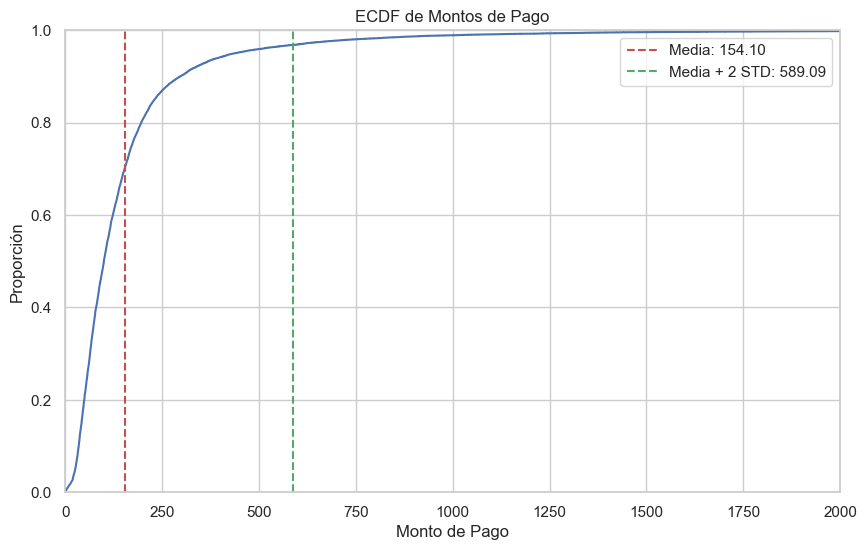

In [30]:
# ECDF
mean_val = order_payments['payment_value'].mean()
std_val = order_payments['payment_value'].std()
upper_limit = mean_val + 2 * std_val

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=order_payments, x='payment_value')
plt.axvline(mean_val, color='r', linestyle='--', label=f'Media: {mean_val:.2f}')
plt.axvline(upper_limit, color='g', linestyle='--', label=f'Media + 2 STD: {upper_limit:.2f}')
plt.title('ECDF de Montos de Pago')
plt.xlabel('Monto de Pago')
plt.ylabel('Proporción')
plt.legend()
plt.xlim(0, 2000)
plt.show()

Podemos observar que mas de un 80% de los pagos se ubican en los monton menores a 250 reales.

### 5. Métodos de Pago: Cantidad, Porcentaje y Boxplots
Análisis detallado de métodos de pago y sus valores.

C:\Users\locu\AppData\Local\Temp\ipykernel_42724\1440273377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')


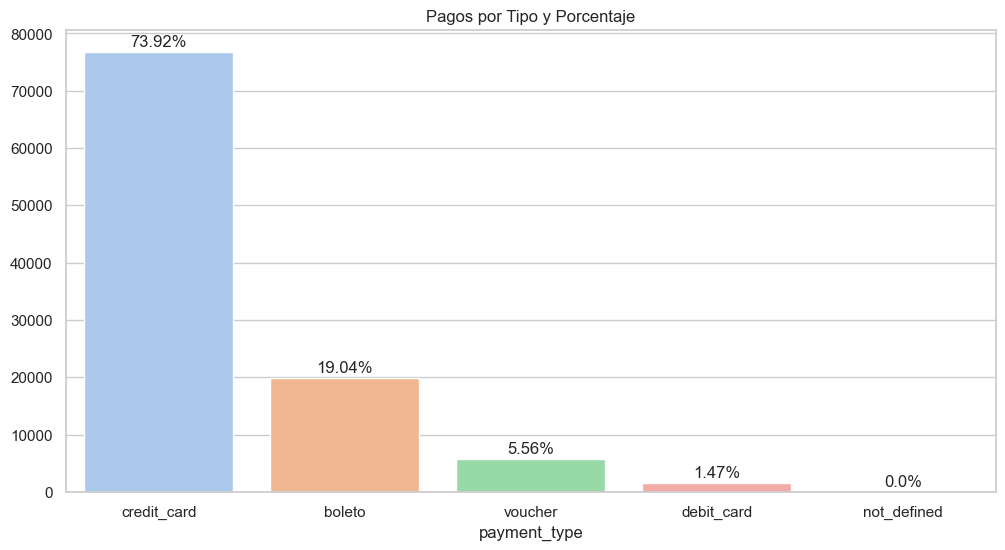

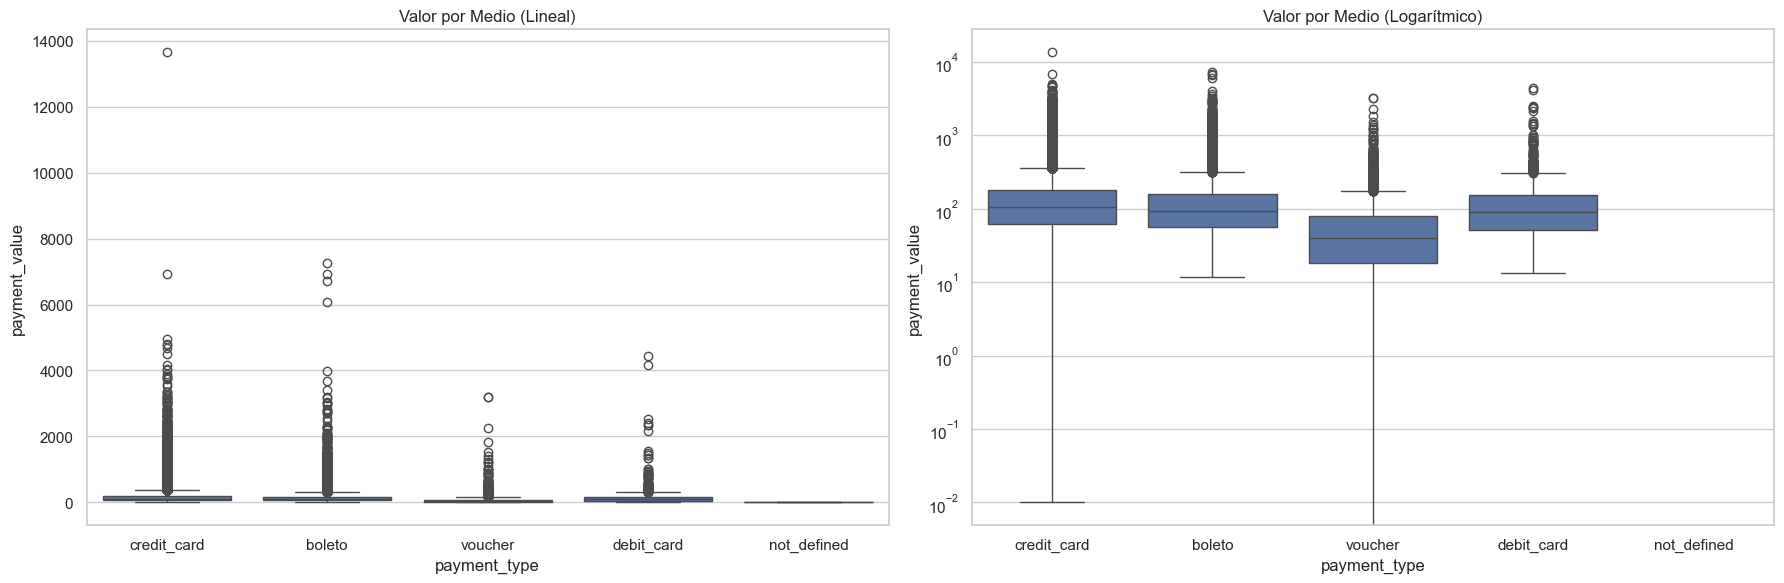

In [26]:
payment_counts = order_payments['payment_type'].value_counts()
payment_pct = (payment_counts / payment_counts.sum() * 100).round(2)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')
plt.title('Pagos por Tipo y Porcentaje')
for i, p in enumerate(ax.patches):
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 1000, f'{payment_pct.iloc[i]}%', ha="center")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=order_payments, x='payment_type', y='payment_value', ax=ax1)
ax1.set_title('Valor por Medio (Lineal)')
sns.boxplot(data=order_payments, x='payment_type', y='payment_value', ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Valor por Medio (Logarítmico)')
plt.tight_layout()
plt.show()

### 6. Relación entre Precio del Pedido y Valor del Flete
Dispersión entre el precio del producto y el costo de envío.

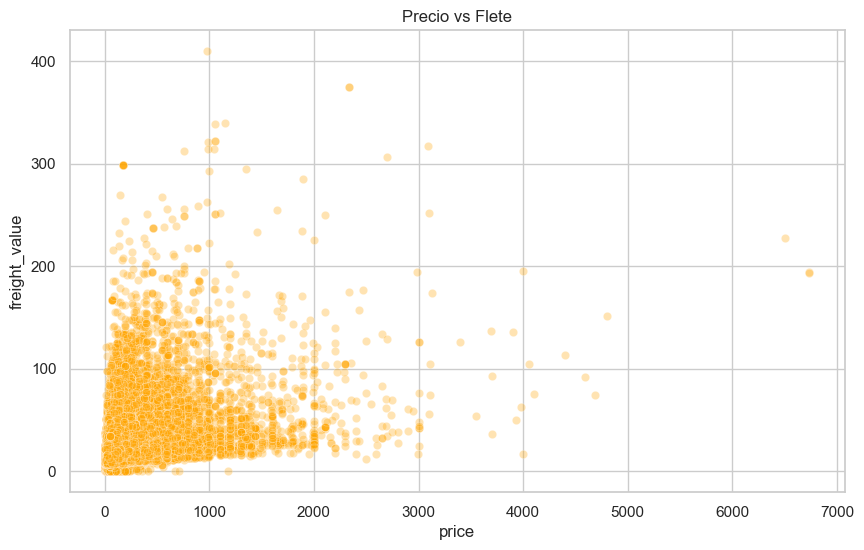

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=order_items, x='price', y='freight_value', alpha=0.3, color='orange')
plt.title('Precio vs Flete')
plt.show()

### 7. Boxplot del Flete por Estado
Variación del flete según ubicación del cliente.

C:\Users\locu\AppData\Local\Temp\ipykernel_42724\2735280243.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_freight, x='customer_state', y='freight_value', order=order_states, palette='coolwarm')


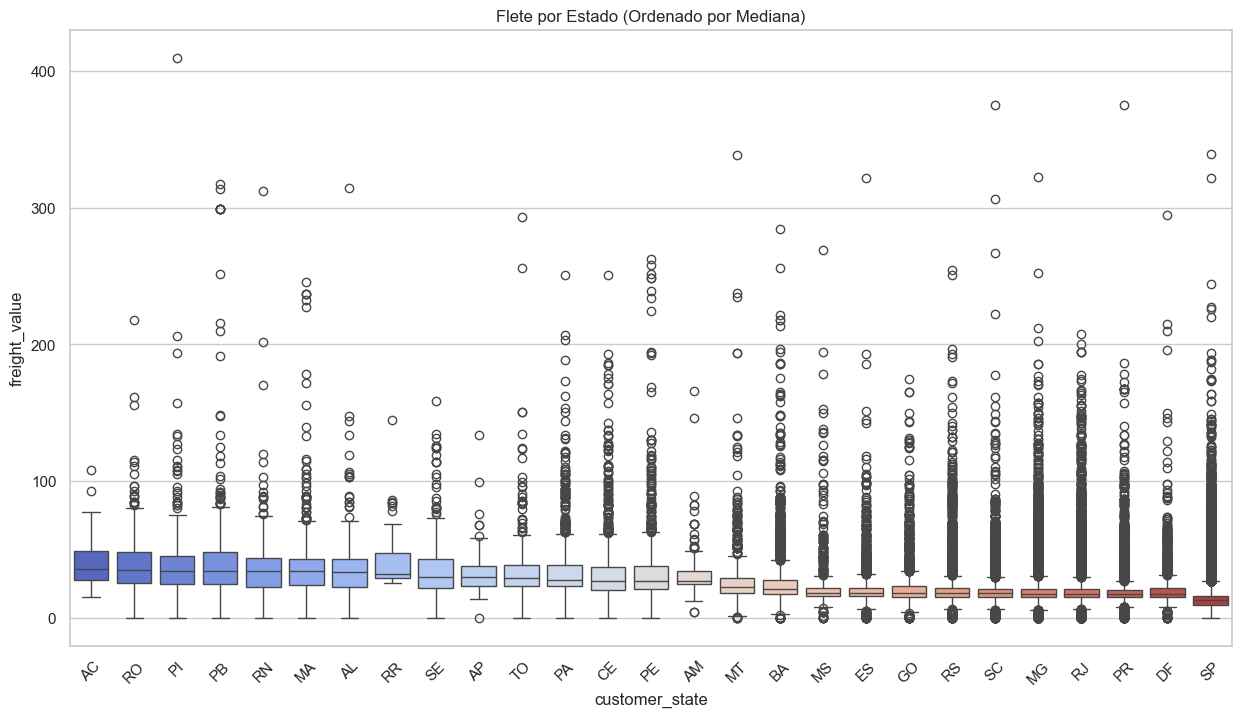

In [28]:
df_freight = order_items.merge(orders, on='order_id').merge(customers, on='customer_id')
plt.figure(figsize=(15, 8))
order_states = df_freight.groupby('customer_state')['freight_value'].median().sort_values(ascending=False).index
sns.boxplot(data=df_freight, x='customer_state', y='freight_value', order=order_states, palette='coolwarm')
plt.title('Flete por Estado (Ordenado por Mediana)')
plt.xticks(rotation=45)
plt.show()